# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [2]:
#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [3]:
print("Número de cada clase:")
print(df["RR_Lyrae"].value_counts())

Número de cada clase:
RR_Lyrae
0    2000
1     483
Name: count, dtype: int64


In [4]:
df.describe()

,u-g,g-r,r-i,i-z,RR_Lyrae
count,2483.000000,2483.000000,2483.000000,2483.000000,2483.000000
mean,0.284691,0.983930,0.103497,0.053991,0.194523
std,0.106890,0.123618,0.056978,0.061693,0.395913
min,-0.141000,0.701000,-0.145000,-0.147000,0.000000
25%,0.249500,0.893000,0.077000,0.013000,0.000000
50%,0.319000,0.971000,0.120000,0.047000,0.000000
75%,0.362000,1.089000,0.141000,0.084000,0.000000
max,0.400000,1.325000,0.218000,0.248000,1.000000


### Preguntas
1. ¿Este es un problema de clasificación o regresión?  
R: Es un problema de clasificación: distingue entre estrellas RR Lyrae, y las que no lo son.
2. ¿Es un problema binario o multiclase?  
R: Es binario en nuestro caso; no nos interesan el tipo de estrellas sino que simplemente si es RR Lyrae o no.
3. ¿Qué representa la variable objetivo?  
R: El tipo de estrella que deseamos identificar.
4. ¿Las clases están balanceadas o desbalanceadas?  
R: Están desbalanceadas, hay bastante más (~ x5 veces) de otro tipo de estrellas que RR Lyraes.

5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?  
R: Si está desbalanceado, el set de datos de entrenamiento se podría escoger de tal forma que no aparezcan ningún dato de RR Lyrae, provocando que el algoritmo obtenga un accuracy perfecto, pero una precisión potencialmente indefinida.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

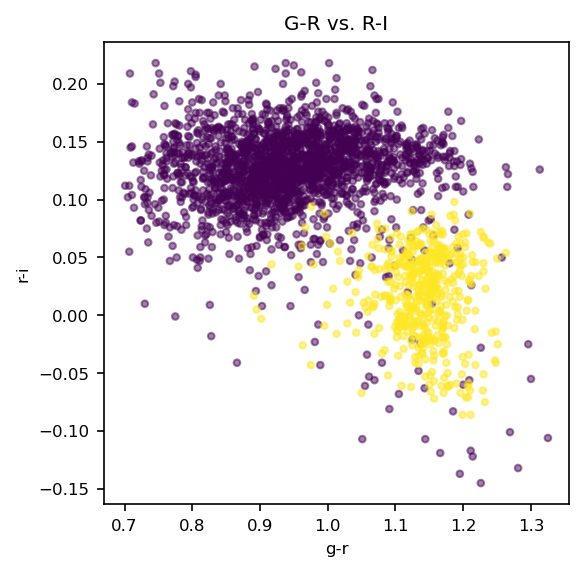

In [5]:
#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df["g-r"], df["r-i"], c=df["RR_Lyrae"], s=10, alpha=0.5)
plt.xlabel("g-r")
plt.ylabel("r-i")
plt.title("G-R vs. R-I")
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?  
R: Hay cierta separación, pero hay regiones en las que se entremezclan las clases.

2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?  
R: No parece haber una separación que pueda formarse con criterios sí/no, al menos con dos features, pero se espera un funcionamiento razonable siempre y cuando se considere el balanceo de los datos.

#### Separe los datos en entrenamiento y prueba

In [6]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?  
R: Podríamos caer en un modelo que entregue un mayor número de falsos negativos en base a la proporción que tenemos de estrellas/RR Lyrae. Una partición desigual introduce un sesgo al modelo que afectará su capacidad de generalizar
2. ¿Por qué eso podría afectar la evaluación del modelo?  
R: Tal como se explica anteriormente, la accuracy del modelo puede ser perfecta si el modelo sólo conoce un tipo de dato, y por tanto se dificultaría la generalización. En tanto, otras métricas como la precisión o el recall consideran la clasificación correcta/incorrecta de los datos y en este caso el modelo presentaría un rendimiento deficiente 
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?  
R: Que se mantenga la proporción negativa/positiva en los sets de datos

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [7]:
model_tree = DecisionTreeClassifier(random_state=42)
#entrene el modelo y genere las predicciones
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

#### Visualicemos el árbol

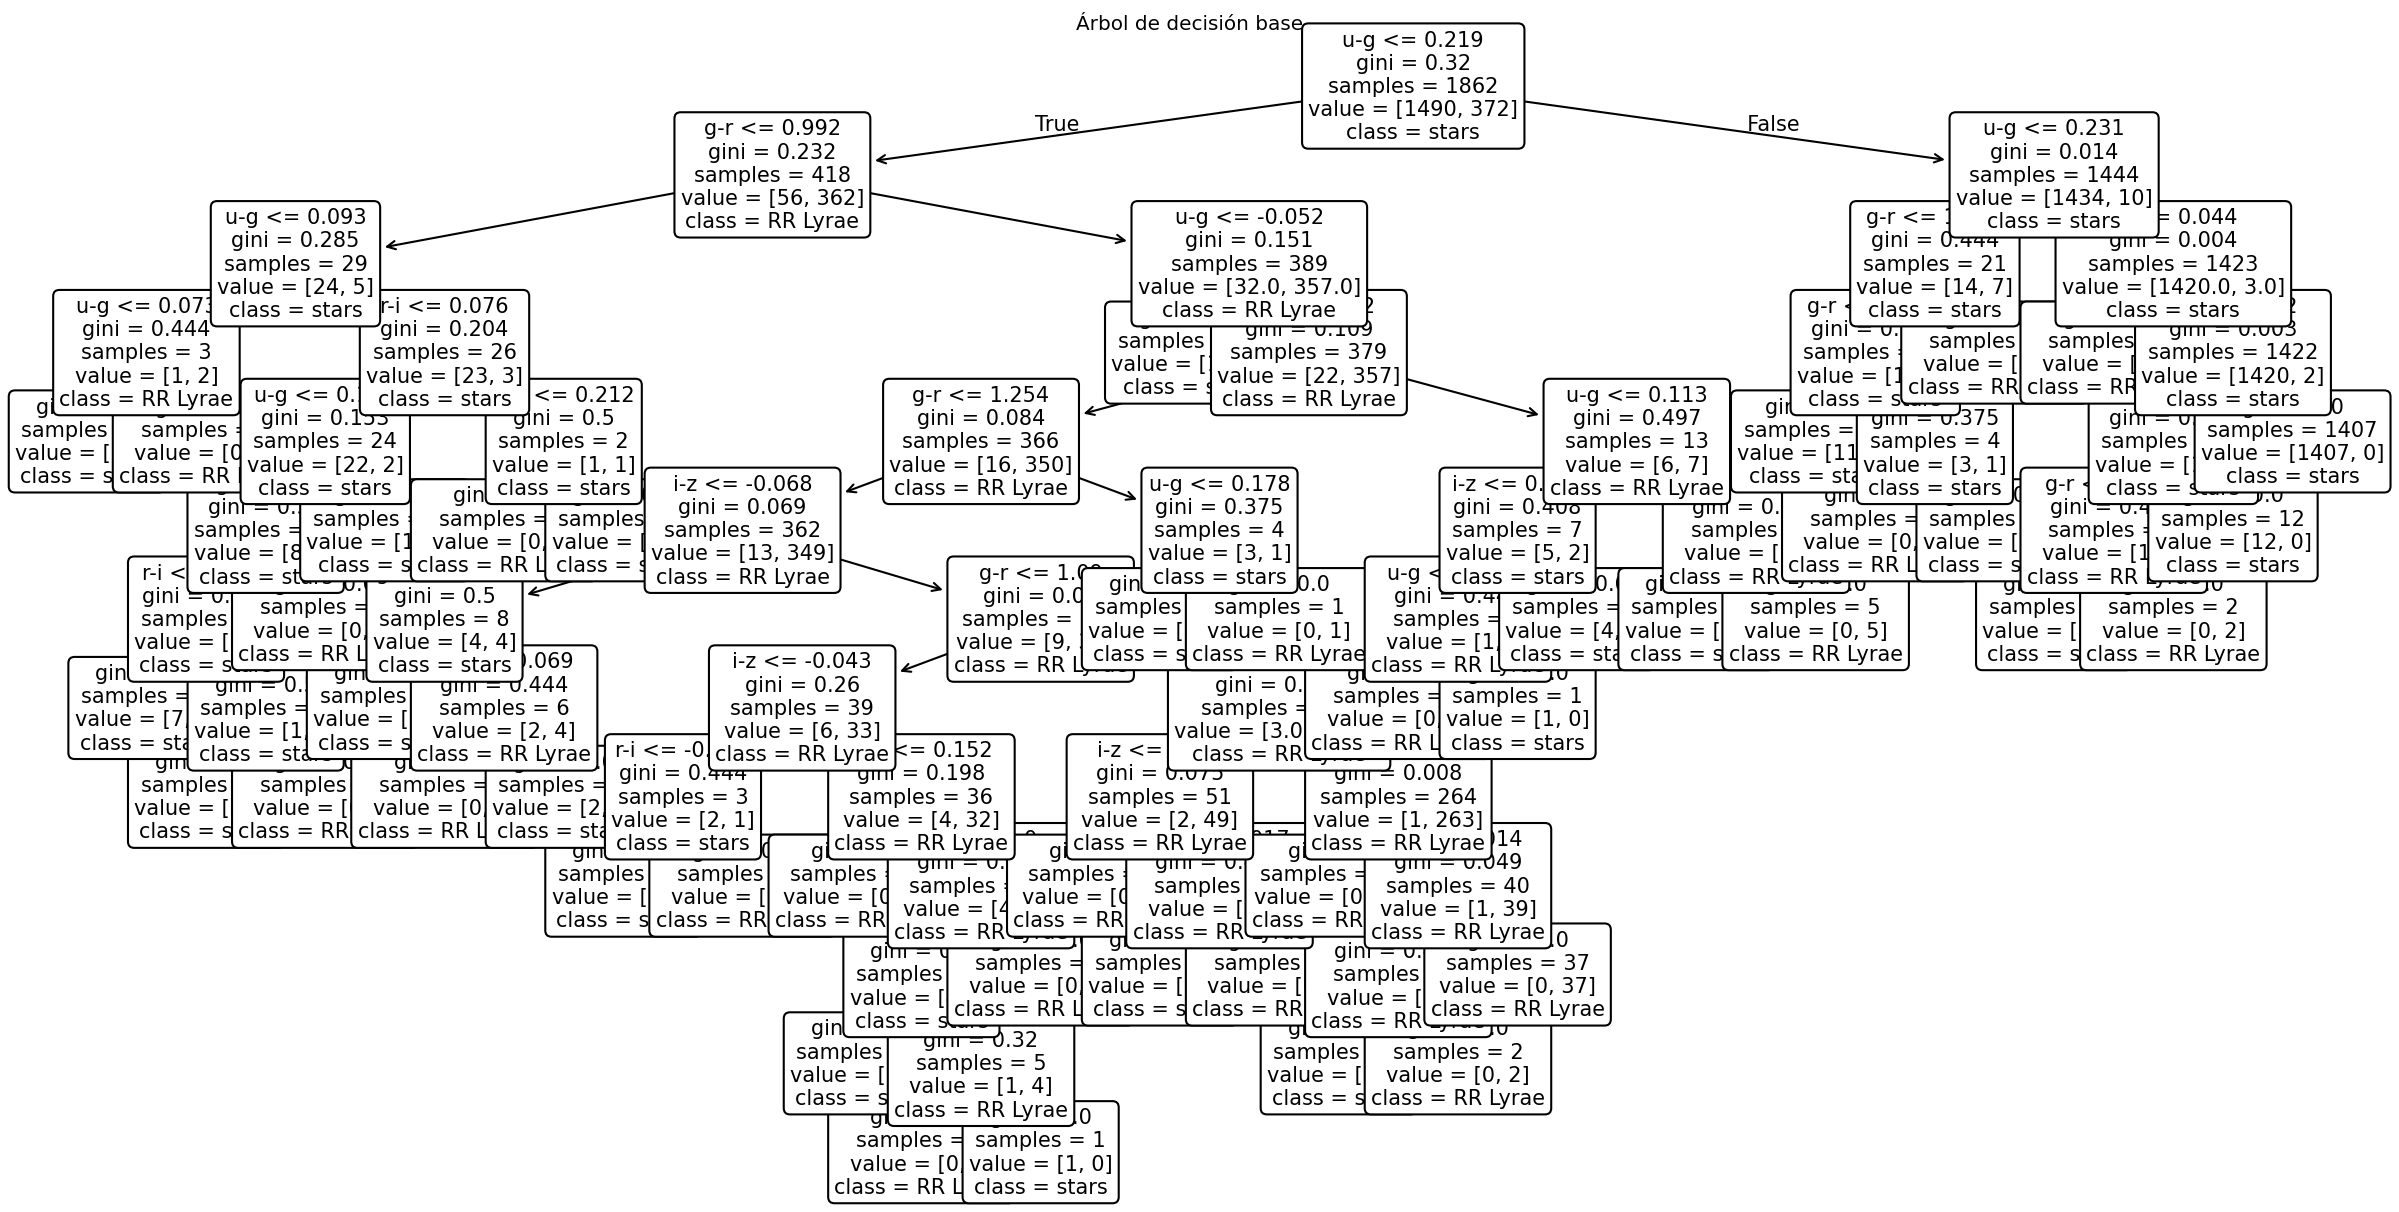

In [8]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

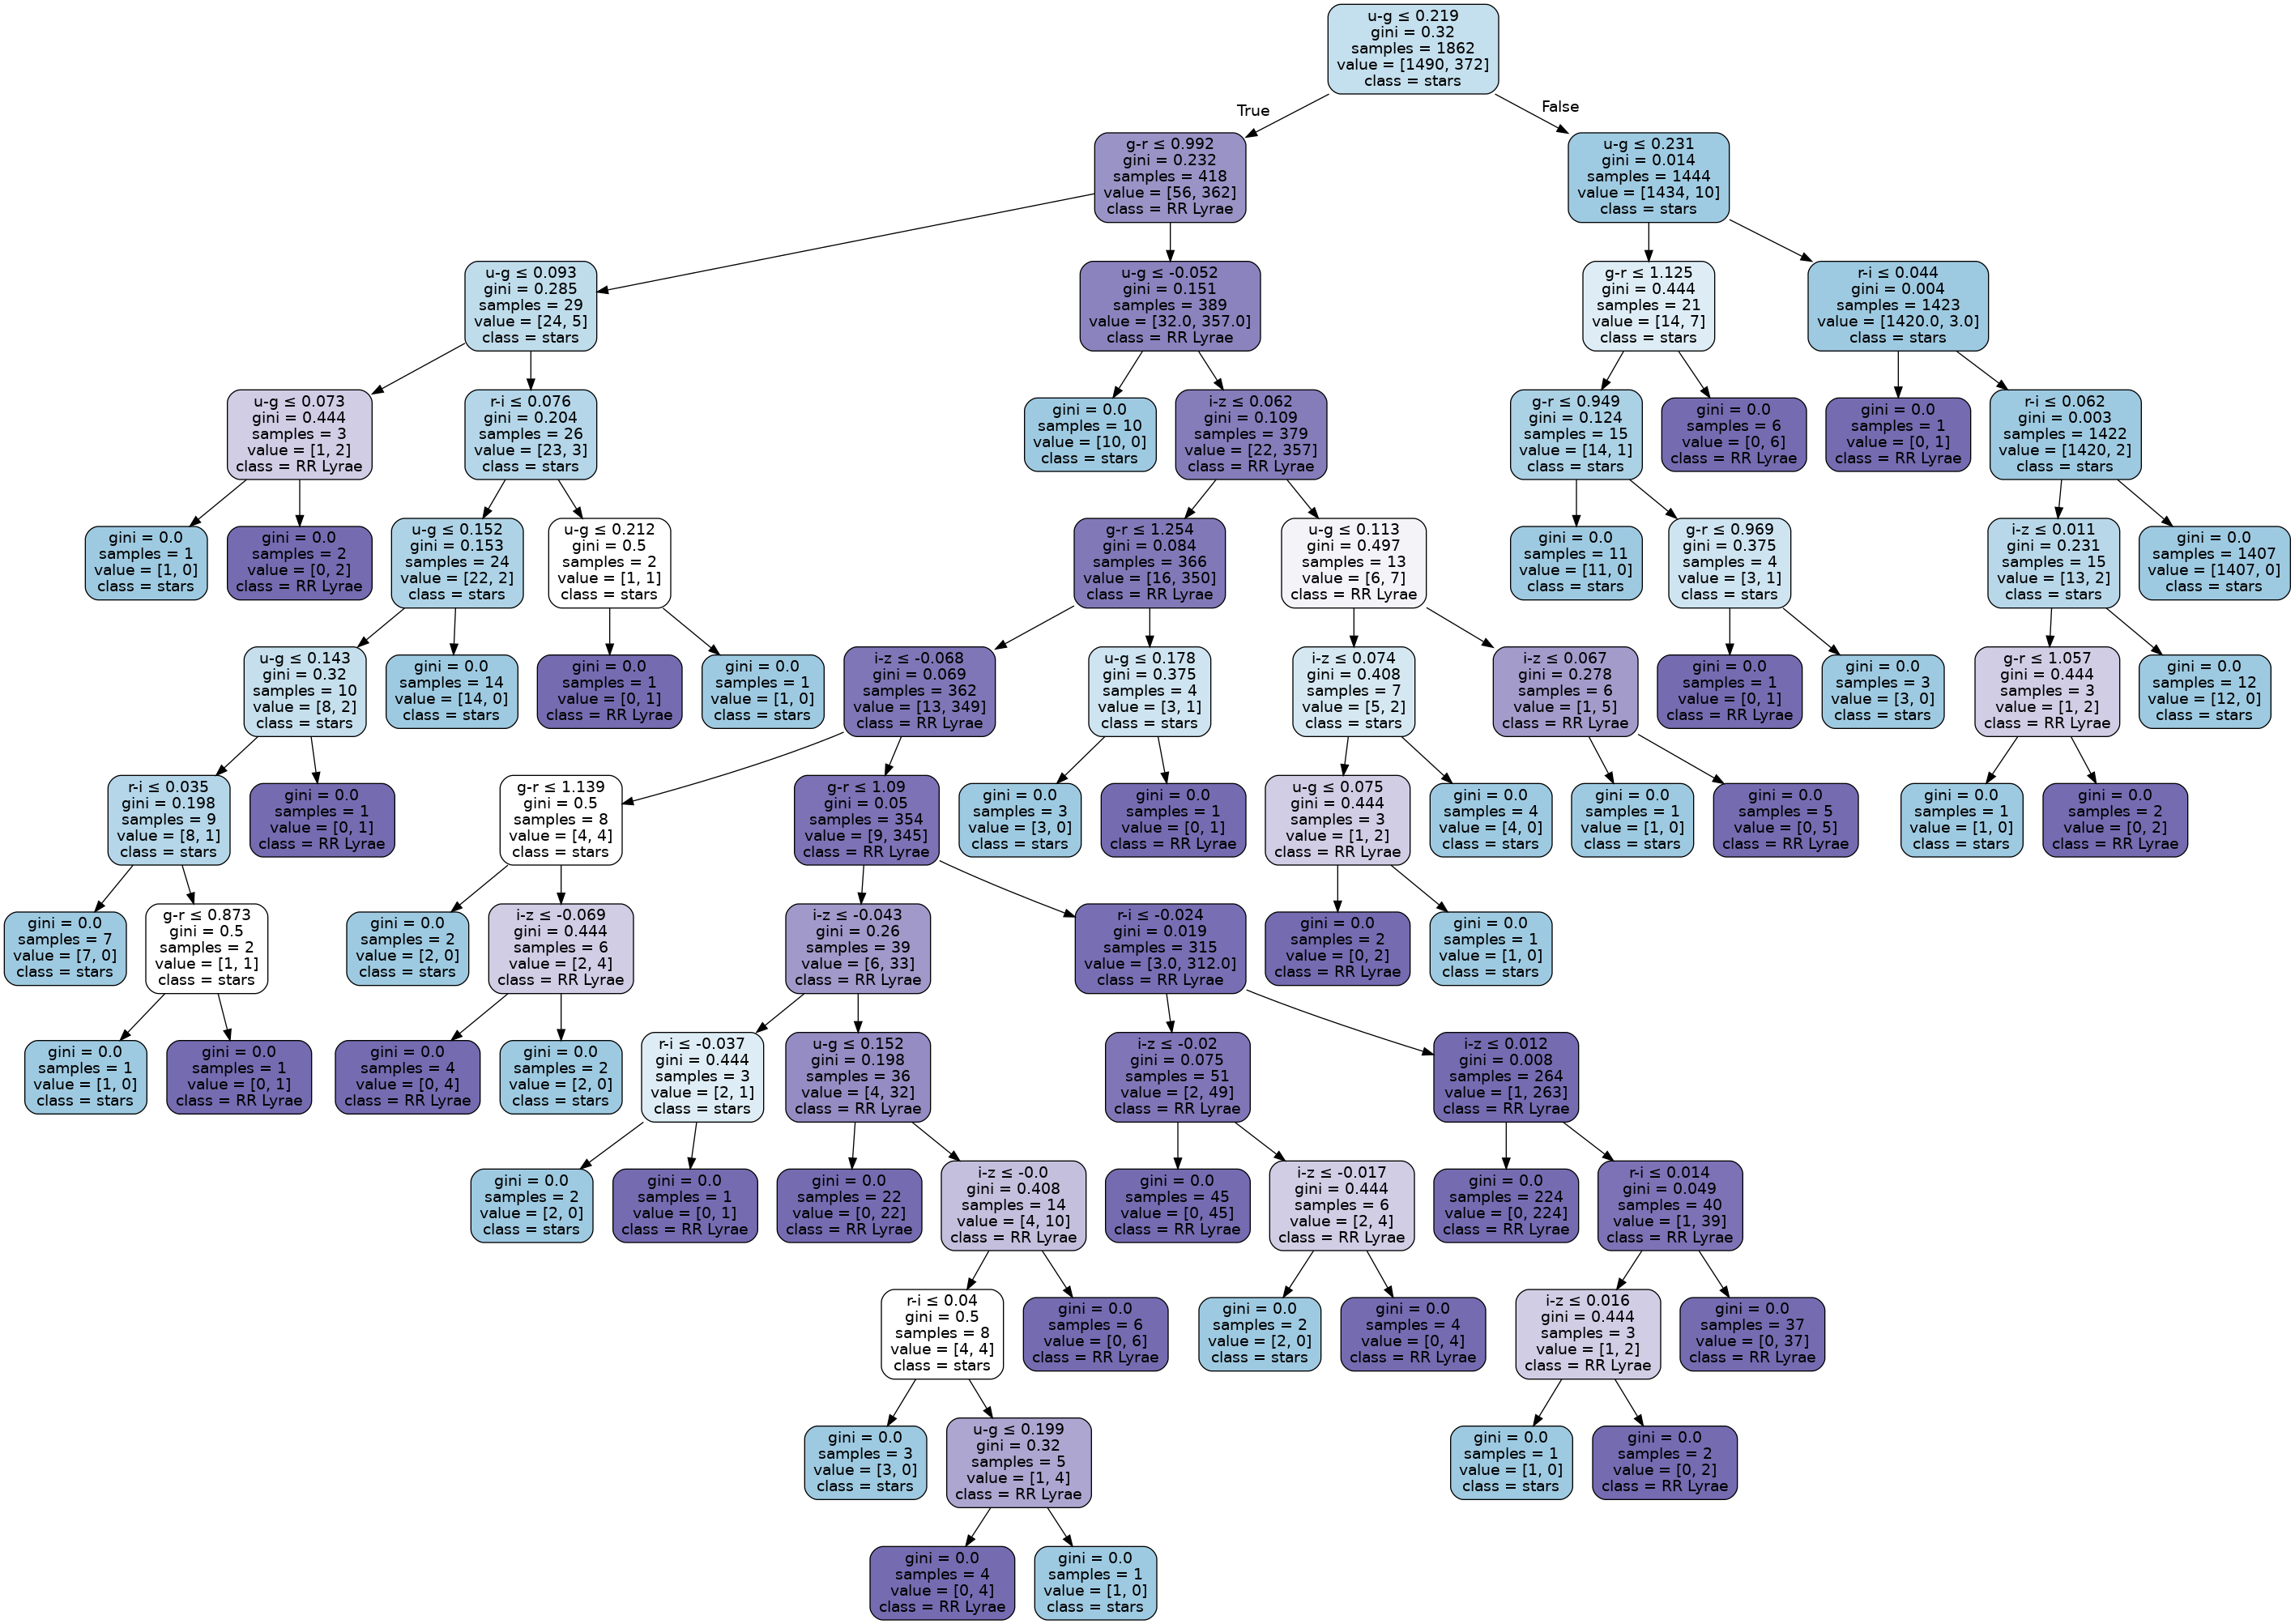

In [9]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.  
Es bastante complejo para sólo tener 4 features. A ojo, presenta más de 10 divisiones que no se justificaría con la cantidad de features a considerar.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?  
Presentaría problemas de sobreajuste a los datos de entrenamiento y por tanto una pobre generalización a datos nuevos.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [10]:
print("Accuracy (Train):", metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print("Accuracy (Test):", metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

Accuracy (Train): 1.0
Accuracy (Test): 0.966183574879227


#### Otras métricas

In [11]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8813559322033898
Recall   : 0.9369369369369369
F1-score : 0.9082969432314411


In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[496,  14],
       [  7, 104]])

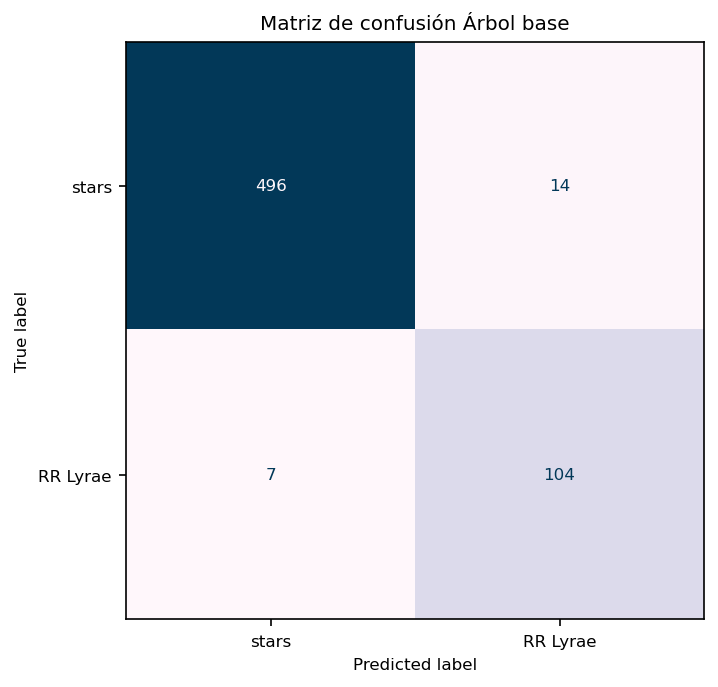

In [13]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



In [14]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1_score)

Precision: 0.8813559322033898
Recall   : 0.9369369369369369
F1-score : 0.908296943231441


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

R: Un falso positivo es una estrella que fue clasificada como RR Lyrae cuando no lo era. Un falso negativo es una estrella que fue clasificada como no-RR Lyrae, cuando sí lo era.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?  
R: Preocuparía más la cantidad de falsos negativos hallados. Esto se puede ver representado por el valor de la completitud

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?  
R: Preocuparía más los falsos positivos hallados, que se ve representado por el valor de la precisión o pureza.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [15]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [16]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7440fb98c4c0>

In [17]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [18]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [19]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [20]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'accuracy')

In [21]:
scores1

{'fit_time': array([0.00594306, 0.00456691, 0.00386691, 0.00399494, 0.00123405]),
 'score_time': array([0.00161958, 0.00139093, 0.00118947, 0.0010314 , 0.00085187]),
 'test_score': array([0.98591549, 0.98189135, 0.96981891, 0.96572581, 0.02620968])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [22]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [23]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.012


In [24]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.004


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [25]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metri

In [26]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [27]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/benja/anaconda3/lib/python3.11/site-packages/sklearn/metri

In [28]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.916 1.000
0.927 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [29]:
#model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model_tree, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [30]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [31]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [32]:
np.sum(y_cv3-y_cv2)

4

In [33]:
np.sum(y_cv2)

485

In [34]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

54

In [35]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [36]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

In [37]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

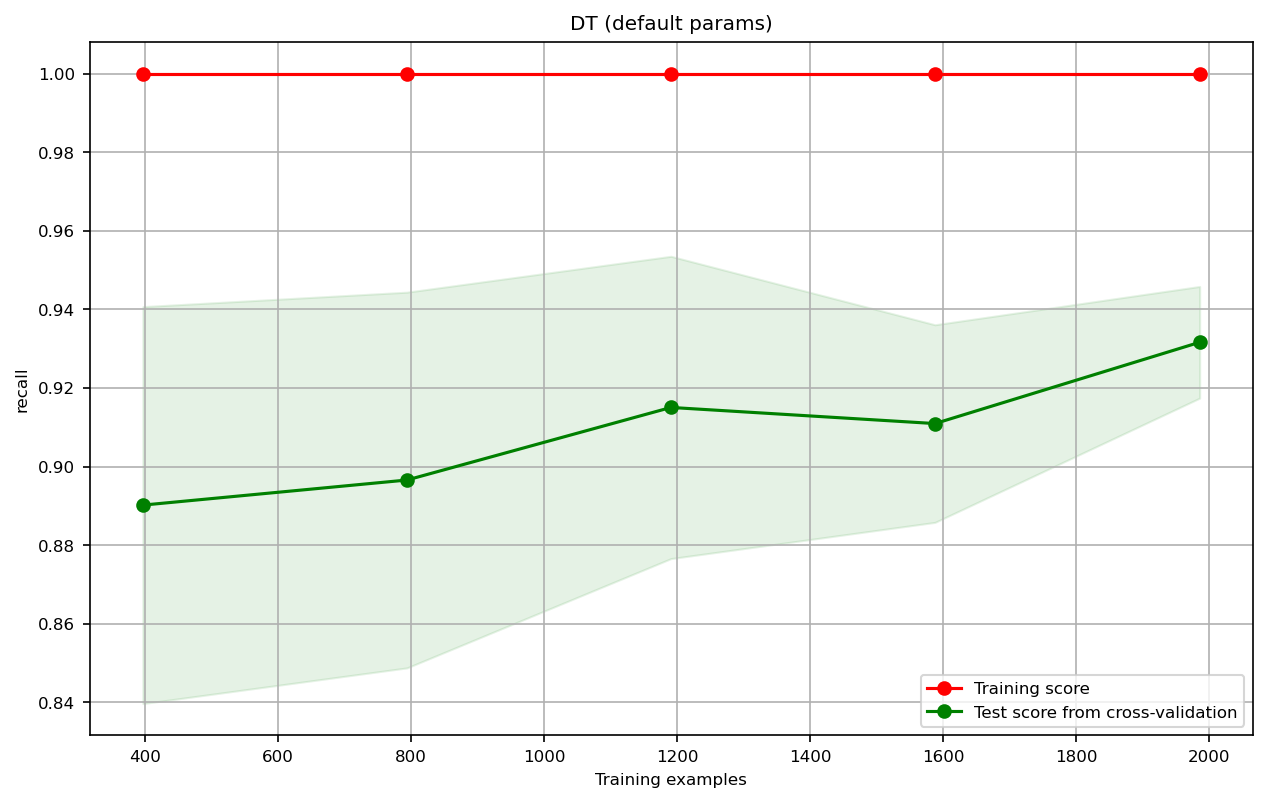

In [38]:
model = DecisionTreeClassifier(random_state = 5)
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

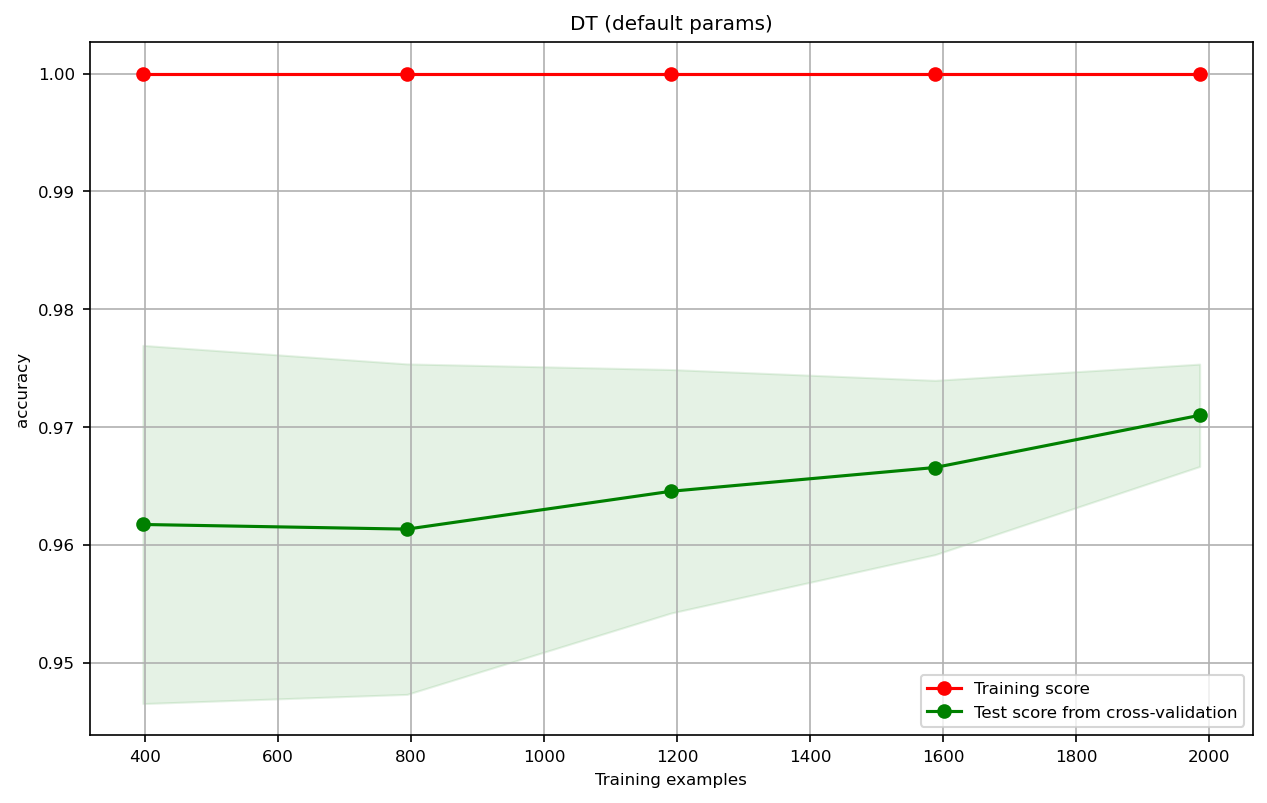

In [39]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?  
R: Sí, aunque pequeña. Podemos inferir que existe un leve sobreajuste a los datos.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?  
R: La curva del test score tiende a subir, por lo que esperaríamos que al agregar más datos nos encontremos con una sección plana en algún momento. Esto considerando en la escala a la que están graficadas las curvas
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
R: Sobreajuste moderado. La varianza no es tan alta, mas no despreciable. El test score es bastante alto por lo que no cae en un sobreajuste excesivo.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.  
El modelo propuesto presenta un rendimiento aceptable dentro del set de datos, sin embargo presenta indicios de leve sobreajuste posiblemente introducido por la selección de los set de entrenamiento y test. La adición de nuevos datos podría ayudar a mejorar el modelo, mas no sería suficiente medida para evitar el sobreajuste. A priori, un recurso en pos de la mejora sería realizar una poda al DecisionTree para evitar una sobredensidad de nodos y con esto lograr un modelo más simple.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

In [40]:
model_tree2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf = 10, random_state=42)
cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=42)
for score in ["accuracy", "precision", "recall", "f1"]:
    scores_model = cross_validate(model_tree2, X, y, cv = cv3, scoring = score, return_train_score=True)
    print(score)

    print("Mean Test Score: {:.3f}, Mean Train Score: {:.3f}".format(scores_model['test_score'].mean(), scores_model['train_score'].mean()))

accuracy
Mean Test Score: 0.969, Mean Train Score: 0.980
precision
Mean Test Score: 0.917, Mean Train Score: 0.941
recall
Mean Test Score: 0.928, Mean Train Score: 0.959
f1
Mean Test Score: 0.922, Mean Train Score: 0.950


In [48]:
print("Rendimiento de árbol base:")
basetree_scores = []
for score in ["accuracy", "precision", "recall", "f1"]:
    scores = cross_validate(model_tree, X, y, cv = cv3, scoring = score, return_train_score=True)
    basetree_scores.append((scores["test_score"].mean(), scores["train_score"].mean()))
    print(score)

    print("Mean Test Score: {:.3f}, Mean Train Score: {:.3f}".format(scores['test_score'].mean(), scores['train_score'].mean()))

Rendimiento de árbol base:
accuracy
Mean Test Score: 0.966, Mean Train Score: 1.000
precision
Mean Test Score: 0.911, Mean Train Score: 1.000
recall
Mean Test Score: 0.915, Mean Train Score: 1.000
f1
Mean Test Score: 0.912, Mean Train Score: 1.000


1. El rendimiento del train test se redujo de 1, cosa que es preferible; y para los test score hubo leves disminuciones con respecto al árbol base.  
2. Mejora la generalización pues no se "aprende" los datos del train set. El StratifiedKFold ayuda en esto, pues entrega sets que conservan la proporción original de los datos, además de aleatorizarlos.
3. Sugiere que efectivamente el árbol base estaba sobreajustando los datos.
4. Dependería del objetivo científico: si buscamos recuperar la mayor cantidad de RR Lyraes reales, preferiríamos este árbol por tener más capacidad de generalizar; si buscamos pureza en el set de datos, podríamos eventualmente usar el árbol base, pero de todas formas sería preferible este segundo modelo.
5. Nuevamente, depende del objetivo científico


## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [49]:
knn_model = KNeighborsClassifier(5)
scaler = StandardScaler()
train, test = next(cv3.split(X,y))
X_train, X_test = X.loc[train], X.loc[test]
y_train, y_test = y.loc[train], y.loc[test]
scaledX_train = scaler.fit_transform(X_train)
scaledX_test = scaler.transform(X_test)

knn_model.fit(scaledX_train, y_train)
y_pred = knn_model.predict(scaledX_test)

In [59]:

for score in ["accuracy", "precision", "recall", "f1"]:
    scaler = StandardScaler()
    knn_model = KNeighborsClassifier(5)
    
    cv_scores = cross_validate(knn_model, X, y, cv=cv3, scoring=score, return_train_score=True)
    print(f"\nkNN (k=5) - {score}")
    print(f"Mean Test Score: {cv_scores['test_score'].mean():.3f}, Mean Train Score: {cv_scores['train_score'].mean():.3f}")
    
    print(f"Árbol Base - {score}")
    idx = ["accuracy", "precision", "recall", "f1"].index(score)
    print(f"Mean Test Score: {basetree_scores[idx][0]:.3f}, Mean Train Score: {basetree_scores[idx][1]:.3f}")



kNN (k=5) - accuracy
Mean Test Score: 0.980, Mean Train Score: 0.983
Árbol Base - accuracy
Mean Test Score: 0.966, Mean Train Score: 1.000

kNN (k=5) - precision
Mean Test Score: 0.926, Mean Train Score: 0.936
Árbol Base - precision
Mean Test Score: 0.911, Mean Train Score: 1.000

kNN (k=5) - recall
Mean Test Score: 0.975, Mean Train Score: 0.981
Árbol Base - recall
Mean Test Score: 0.915, Mean Train Score: 1.000

kNN (k=5) - f1
Mean Test Score: 0.950, Mean Train Score: 0.958
Árbol Base - f1
Mean Test Score: 0.912, Mean Train Score: 1.000


In [60]:
ks = [1, 3,  7, 9, 21]
knn_rows = []
for k in ks:
    knn_model = KNeighborsClassifier(k)
    knn_rows.append({'k': k})
    for score in ["accuracy", "precision", "recall", "f1"]:
        cv_scores = cross_validate(knn_model, X, y, cv=cv3, scoring=score, return_train_score=True)
        knn_rows[-1][f'{score}_test'] = cv_scores['test_score'].mean()
        knn_rows[-1][f'{score}_train'] = cv_scores['train_score'].mean()

knn_results = pd.DataFrame(knn_rows)
knn_results

,k,accuracy_test,accuracy_train,precision_test,precision_train,recall_test,recall_train,f1_test,f1_train
0,1,0.973011,1.000000,0.922256,1.000000,0.942010,1.000000,0.931520,1.000000
1,3,0.979861,0.985803,0.931523,0.951694,0.968943,0.976703,0.949540,0.963999
2,7,0.977442,0.980265,0.916969,0.924337,0.973046,0.978775,0.944012,0.950743
3,9,0.977041,0.978151,0.915406,0.917739,0.973067,0.975152,0.943164,0.945560
4,21,0.972613,0.973419,0.895864,0.897565,0.973067,0.974635,0.932758,0.934503


1. Tienen un rendimiento bastante similar, aunque kNN con k=5 es ligeramente mejor, y además no sobreajusta los datos
2. Tiende a sobreajustar, cosa que podemos inferir de las métricas en el train 
3. Empeora el rendimiento general del modelo: las métricas caen levemente.
4. De la métrica F1, leemos que para k=3, y k=5 esta toma sus máximos valores, que podemos interpretar como un balance entre precision y recall.
5. Sería más fácil para kNN ajustar, pues no toma decisiones basadas en intervalos, sino que en base a distancias respecto a otros datos.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.